In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset

In [ ]:
dataset = load_dataset("CShorten/ML-ArXiv-Papers",split='train')

In [ ]:
print(dataset)

Dataset({
    features: ['Unnamed: 0.1', 'Unnamed: 0', 'title', 'abstract'],
    num_rows: 117592
})


In [ ]:
dataset[0]

{'Unnamed: 0.1': 0,
 'Unnamed: 0': 0.0,
 'title': 'Learning from compressed observations',
 'abstract': '  The problem of statistical learning is to construct a predictor of a random\nvariable $Y$ as a function of a related random variable $X$ on the basis of an\ni.i.d. training sample from the joint distribution of $(X,Y)$. Allowable\npredictors are drawn from some specified class, and the goal is to approach\nasymptotically the performance (expected loss) of the best predictor in the\nclass. We consider the setting in which one has perfect observation of the\n$X$-part of the sample, while the $Y$-part has to be communicated at some\nfinite bit rate. The encoding of the $Y$-values is allowed to depend on the\n$X$-values. Under suitable regularity conditions on the admissible predictors,\nthe underlying family of probability distributions and the loss function, we\ngive an information-theoretic characterization of achievable predictor\nperformance in terms of conditional distortion-rat

In [ ]:
import pandas as pd

In [ ]:
df=pd.DataFrame(dataset)
df

,Unnamed: 0.1,Unnamed: 0,title,abstract
0,0,0.0,Learning from compressed observations,The problem of statistical learning is to co...
1,1,1.0,Sensor Networks with Random Links: Topology De...,"In a sensor network, in practice, the commun..."
2,2,2.0,The on-line shortest path problem under partia...,The on-line shortest path problem is conside...
3,3,3.0,A neural network approach to ordinal regression,Ordinal regression is an important type of l...
4,4,4.0,Parametric Learning and Monte Carlo Optimization,This paper uncovers and explores the close r...
...,...,...,...,...
117587,4995,NaN,Detecting COVID-19 Conspiracy Theories with Tr...,The sharing of fake news and conspiracy theori...
117588,4996,NaN,Fair Feature Subset Selection using Multiobjec...,The feature subset selection problem aims at s...
117589,4997,NaN,A Simple Duality Proof for Wasserstein Distrib...,We present a short and elementary proof of the...
117590,4998,NaN,Combined Learning of Neural Network Weights fo...,"We introduce CoLN, Combined Learning of Neural..."


In [ ]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'title', 'abstract'], dtype='object')

In [ ]:
df=df[['title','abstract']]

In [ ]:
df

,title,abstract
0,Learning from compressed observations,The problem of statistical learning is to co...
1,Sensor Networks with Random Links: Topology De...,"In a sensor network, in practice, the commun..."
2,The on-line shortest path problem under partia...,The on-line shortest path problem is conside...
3,A neural network approach to ordinal regression,Ordinal regression is an important type of l...
4,Parametric Learning and Monte Carlo Optimization,This paper uncovers and explores the close r...
...,...,...
117587,Detecting COVID-19 Conspiracy Theories with Tr...,The sharing of fake news and conspiracy theori...
117588,Fair Feature Subset Selection using Multiobjec...,The feature subset selection problem aims at s...
117589,A Simple Duality Proof for Wasserstein Distrib...,We present a short and elementary proof of the...
117590,Combined Learning of Neural Network Weights fo...,"We introduce CoLN, Combined Learning of Neural..."


In [ ]:
df.shape

(117592, 2)

In [ ]:
df=df.head(15000)

In [ ]:
df.isnull().sum()

,0
title,0
abstract,0


In [ ]:
df.loc[:, "paper_text"] = df["title"] + " " + df["abstract"]

/tmp/ipykernel_20076/1740363480.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "paper_text"] = df["title"] + " " + df["abstract"]


In [ ]:
df["paper_text"].head()

,paper_text
0,Learning from compressed observations The pr...
1,Sensor Networks with Random Links: Topology De...
2,The on-line shortest path problem under partia...
3,A neural network approach to ordinal regressio...
4,Parametric Learning and Monte Carlo Optimizati...


In [ ]:
type(df[["paper_text"]])

pandas.core.frame.DataFrame

In [ ]:
print(df["paper_text"].iloc[0])

Learning from compressed observations   The problem of statistical learning is to construct a predictor of a random
variable $Y$ as a function of a related random variable $X$ on the basis of an
i.i.d. training sample from the joint distribution of $(X,Y)$. Allowable
predictors are drawn from some specified class, and the goal is to approach
asymptotically the performance (expected loss) of the best predictor in the
class. We consider the setting in which one has perfect observation of the
$X$-part of the sample, while the $Y$-part has to be communicated at some
finite bit rate. The encoding of the $Y$-values is allowed to depend on the
$X$-values. Under suitable regularity conditions on the admissible predictors,
the underlying family of probability distributions and the loss function, we
give an information-theoretic characterization of achievable predictor
performance in terms of conditional distortion-rate functions. The ideas are
illustrated on the example of nonparametric regress

In [ ]:
from sentence_transformers import SentenceTransformer

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [ ]:
print(type(model))

<class 'sentence_transformers.sentence_transformer.model.SentenceTransformer'>


In [ ]:
Simple_text = df["paper_text"].iloc[0]

In [ ]:
print(df["paper_text"].dtype)
print(type(df["paper_text"].iloc[0]))
print(df["paper_text"].head())

object
<class 'str'>
0    Learning from compressed observations   The pr...
1    Sensor Networks with Random Links: Topology De...
2    The on-line shortest path problem under partia...
3    A neural network approach to ordinal regressio...
4    Parametric Learning and Monte Carlo Optimizati...
Name: paper_text, dtype: object


In [ ]:
df.loc[:, "paper_text"] = (
    df["title"].fillna("").astype(str)
    + " "
    + df["abstract"].fillna("").astype(str)
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.loc[:, "paper_text"] = df["paper_text"].str.replace("\n", " ", regex=False)
df.loc[:, "paper_text"] = df["paper_text"].str.strip()

In [ ]:
Simple_text = df["paper_text"].iloc[0]
Simple_text

'Learning from compressed observations   The problem of statistical learning is to construct a predictor of a random variable $Y$ as a function of a related random variable $X$ on the basis of an i.i.d. training sample from the joint distribution of $(X,Y)$. Allowable predictors are drawn from some specified class, and the goal is to approach asymptotically the performance (expected loss) of the best predictor in the class. We consider the setting in which one has perfect observation of the $X$-part of the sample, while the $Y$-part has to be communicated at some finite bit rate. The encoding of the $Y$-values is allowed to depend on the $X$-values. Under suitable regularity conditions on the admissible predictors, the underlying family of probability distributions and the loss function, we give an information-theoretic characterization of achievable predictor performance in terms of conditional distortion-rate functions. The ideas are illustrated on the example of nonparametric regres

In [ ]:
print(df["paper_text"].dtype)
print(type(df["paper_text"].iloc[0]))

object
<class 'str'>


In [ ]:
embedding=model.encode(Simple_text)
print(type(embedding))
print(embedding.shape)

<class 'numpy.ndarray'>
(384,)


In [ ]:
embedding[:5]

array([-0.1315641 , -0.00678266, -0.00367612,  0.03265158,  0.11219642],
      dtype=float32)

In [ ]:
texts = df["paper_text"].head(5).tolist()

print(type(texts))
print(texts)

<class 'list'>
['Learning from compressed observations   The problem of statistical learning is to construct a predictor of a random variable $Y$ as a function of a related random variable $X$ on the basis of an i.i.d. training sample from the joint distribution of $(X,Y)$. Allowable predictors are drawn from some specified class, and the goal is to approach asymptotically the performance (expected loss) of the best predictor in the class. We consider the setting in which one has perfect observation of the $X$-part of the sample, while the $Y$-part has to be communicated at some finite bit rate. The encoding of the $Y$-values is allowed to depend on the $X$-values. Under suitable regularity conditions on the admissible predictors, the underlying family of probability distributions and the loss function, we give an information-theoretic characterization of achievable predictor performance in terms of conditional distortion-rate functions. The ideas are illustrated on the example of nonp

In [ ]:
sample_embedding=model.encode(df["paper_text"].head(5).to_list())

In [ ]:
print(sample_embedding.shape)

(5, 384)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
similarity=cosine_similarity(sample_embedding[0].reshape(1, -1),sample_embedding[1].reshape(1, -1))
print(similarity)

[[0.36625272]]


In [ ]:
for i in range(1,5):
  sim=cosine_similarity(sample_embedding[0].reshape(1, -1),sample_embedding[i].reshape(1, -1))
  print(sim)

[[0.36625272]]
[[0.33522844]]
[[0.15505108]]
[[0.37421533]]


Generate full embedding

In [ ]:
embedding = model.encode(
    df["paper_text"].to_list(),
    batch_size=32,
    show_progress_bar=True
)

Batches:   0%|          | 0/469 [00:00<?, ?it/s]

In [ ]:
print(embedding.shape)
print(type(embedding))

(15000, 384)
<class 'numpy.ndarray'>


In [ ]:
embedding.dtype

dtype('float32')

In [ ]:
!pip install faiss-cpu

In [ ]:
import faiss

In [ ]:
faiss.normalize_L2(embedding)

In [ ]:
index=faiss.IndexFlatIP(384)

In [ ]:
index.add(embedding)

In [ ]:
print(index.ntotal)

15000


In [ ]:
query="deep learning for medical image analysis"
query_embedding=model.encode([query])
query_embedding.shape

(1, 384)

In [ ]:
faiss.normalize_L2(query_embedding)

In [ ]:
D,I=index.search(query_embedding,5)
print(D)
print(I)

[[0.6807244  0.67092204 0.65219975 0.62811744 0.61311525]]
[[10466 13730 11873 12691 11282]]


In [ ]:
import os
import numpy as np
if os.path.exists("paper_embeddings.npy"):

  print("Loading saved embedding")

  embeddings = np.load("paper_embeddings.npy")
else:

    print("Generating embeddings")

    embeddings = model.encode(
        df["paper_text"].tolist(),
        batch_size=32,
        show_progress_bar=True
    )

    np.save("paper_embeddings.npy", embedding)
    print("Embeddings saved successfully!")

Loading saved embedding


In [ ]:
if os.path.exists("paper_faiss.index"):
  print("Loading existing FAISS index")
  index = faiss.read_index("paper_faiss.index")
else:
  print("Creating new FAISS index")
  index = faiss.IndexFlatIP(384)
  index.add(embeddings)
  faiss.write_index(index,"paper_faiss.index")
  print("FAISS index saved sucessfully!")

Loading existing FAISS index


In [ ]:
print(df.iloc[10466]["title"])

A Perspective on Deep Imaging


In [ ]:
print(df.iloc[10466]["abstract"])

  The combination of tomographic imaging and deep learning, or machine learning
in general, promises to empower not only image analysis but also image
reconstruction. The latter aspect is considered in this perspective article
with an emphasis on medical imaging to develop a new generation of image
reconstruction theories and techniques. This direction might lead to
intelligent utilization of domain knowledge from big data, innovative
approaches for image reconstruction, and superior performance in clinical and
preclinical applications. To realize the full impact of machine learning on
medical imaging, major challenges must be addressed.



In [ ]:
def search_paper(query,k=5):
  query_embedding=model.encode([query])
  faiss.normalize_L2(query_embedding)
  D,I=index.search(query_embedding,k)
  return D,I

In [ ]:
D,I=search_paper("deep learning for medical image analysis")
print(D)
print(I)

[[0.6807244  0.670922   0.65219975 0.6281173  0.61311525]]
[[10466 13730 11873 12691 11282]]


Similarity score

In [ ]:
def search_paper(query,k=5):
  query_embedding=model.encode([query])
  faiss.normalize_L2(query_embedding)
  D,I=index.search(query_embedding,k)
  for score,idx in zip(D[0],I[0]):
    print("Similarity score",score)
    print("Title",df.iloc[idx]["title"])
    print("Title",df.iloc[idx]["abstract"][:500])

Keyword Extraction

In [ ]:
!pip install keybert

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 1.0 MB/s eta 0:00:00


In [ ]:
from keybert import KeyBERT

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [ ]:
kw_model = KeyBERT(model)

In [ ]:
type(kw_model)

keybert._model.KeyBERT

In [ ]:
print(df.iloc[10466]["abstract"])

  The combination of tomographic imaging and deep learning, or machine learning
in general, promises to empower not only image analysis but also image
reconstruction. The latter aspect is considered in this perspective article
with an emphasis on medical imaging to develop a new generation of image
reconstruction theories and techniques. This direction might lead to
intelligent utilization of domain knowledge from big data, innovative
approaches for image reconstruction, and superior performance in clinical and
preclinical applications. To realize the full impact of machine learning on
medical imaging, major challenges must be addressed.



In [ ]:
text = df.iloc[10466]["abstract"]
keywords = kw_model.extract_keywords(text)

In [ ]:
print(keywords)

[('imaging', 0.4528), ('tomographic', 0.4488), ('reconstruction', 0.3623), ('deep', 0.3003), ('learning', 0.2622)]


In [ ]:
print(type(keywords))

<class 'list'>


In [ ]:
print(type(keywords[0]))

<class 'tuple'>


In [ ]:
keywords=kw_model.extract_keywords(text,keyphrase_ngram_range=(1, 3), stop_words="english")
print(keywords)

[('tomographic imaging deep', 0.6704), ('imaging deep learning', 0.6543), ('learning medical imaging', 0.6041), ('imaging deep', 0.5919), ('medical imaging', 0.5281)]


In [ ]:
keywords = kw_model.extract_keywords(
    text,
    keyphrase_ngram_range=(1, 3),
    stop_words="english"
)

print(keywords)

for k, s in keywords:
    print(k)

[('tomographic imaging deep', 0.6704), ('imaging deep learning', 0.6543), ('learning medical imaging', 0.6041), ('imaging deep', 0.5919), ('medical imaging', 0.5281)]
tomographic imaging deep
imaging deep learning
learning medical imaging
imaging deep
medical imaging


Named Entity Recognition (NER)

In [ ]:
!pip install -q spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 72.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
print(df.shape)

(15000, 3)


In [ ]:
len(df)

15000

In [ ]:
import pandas as pd
import spacy

In [ ]:
nlp = spacy.load("en_core_web_sm")

In [ ]:
def extract_entities(text):
    if pd.isna(text):
        return []

    text = str(text)

    doc = nlp(text)

    return [(ent.text, ent.label_) for ent in doc.ents]

In [ ]:
sample_df = df.head(500).copy()


In [ ]:
sample_df["Entities"] = sample_df["abstract"].apply(extract_entities)

In [ ]:
sample_df[["title", "Entities"]].head(10)

,title,Entities
0,Learning from compressed observations,"[(X$, MONEY), (X$-part, MONEY), (Y$-part, PERS..."
1,Sensor Networks with Random Links: Topology De...,"[(3, CARDINAL), (SNR, ORG), (SNR, ORG), (1, CA..."
2,The on-line shortest path problem under partia...,"[(two, CARDINAL), (1/\sqrt{n, CARDINAL)]"
3,A neural network approach to ordinal regression,"[(NNRank, ORG), (Gaussian, NORP), (NNRank, ORG..."
4,Parametric Learning and Monte Carlo Optimization,"[(Monte Carlo\nOptimization, PERSON), (MCO, OR..."
5,Preconditioned Temporal Difference Learning,"[(english, LANGUAGE), (ICML, ORG)]"
6,A Note on the Inapproximability of Correlation...,"[(two, CARDINAL), (MaxAgree, ORG), (MinDisagre..."
7,Joint universal lossy coding and identificatio...,"[(Rissanen, GPE), (Vapnik-Chervonenkis, ORG)]"
8,Supervised Feature Selection via Dependence Es...,"[(Hilbert-Schmidt Independence Criterion, ORG)..."
9,Equivalence of LP Relaxation and Max-Product f...,"[(Max, PERSON), (max, PERSON), (first, ORDINAL..."


In [ ]:
sample_df.to_csv("research_papers_with_entities.csv", index=False)

print("NER completed successfully!")
print("Processed Papers:", len(sample_df))

NER completed successfully!
Processed Papers: 500



Similar Paper Recommendation

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def similar_papers(index, top_n=5):

    similarity = cosine_similarity(
        [embeddings[index]],
        embeddings
    )[0]

    similar = similarity.argsort()[::-1][1:top_n+1]

    return df.iloc[similar][["title"]]

similar_papers(0)

,title
208,Achievability results for statistical learning...
9237,Rate-Distortion Bounds on Bayes Risk in Superv...
2980,Sparse Signal Processing with Linear and Nonli...
10270,"Uniform Generalization, Concentration, and Ada..."
10749,On statistical learning via the lens of compre...


Reading Time Estimation

In [ ]:
import math

def reading_time(text):
    if pd.isna(text):
        return 0

    words = len(str(text).split())

    return math.ceil(words / 200)

df["Reading_Time_Min"] = df["abstract"].apply(reading_time)

df[["title", "Reading_Time_Min"]].head(10)

/tmp/ipykernel_20076/4190948764.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Reading_Time_Min"] = df["abstract"].apply(reading_time)


,title,Reading_Time_Min
0,Learning from compressed observations,1
1,Sensor Networks with Random Links: Topology De...,2
2,The on-line shortest path problem under partia...,2
3,A neural network approach to ordinal regression,1
4,Parametric Learning and Monte Carlo Optimization,1
5,Preconditioned Temporal Difference Learning,1
6,A Note on the Inapproximability of Correlation...,2
7,Joint universal lossy coding and identificatio...,1
8,Supervised Feature Selection via Dependence Es...,1
9,Equivalence of LP Relaxation and Max-Product f...,2


Abstract Length Analysis

In [ ]:
def abstract_length(text):
    if pd.isna(text):
        return 0

    return len(str(text).split())

df["Abstract_Length"] = df["abstract"].apply(abstract_length)

df[["title", "Abstract_Length"]].head(10)

/tmp/ipykernel_20076/923008553.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Abstract_Length"] = df["abstract"].apply(abstract_length)


,title,Abstract_Length
0,Learning from compressed observations,150
1,Sensor Networks with Random Links: Topology De...,266
2,The on-line shortest path problem under partia...,281
3,A neural network approach to ordinal regression,129
4,Parametric Learning and Monte Carlo Optimization,197
5,Preconditioned Temporal Difference Learning,38
6,A Note on the Inapproximability of Correlation...,224
7,Joint universal lossy coding and identificatio...,90
8,Supervised Feature Selection via Dependence Es...,76
9,Equivalence of LP Relaxation and Max-Product f...,213


Visualize Abstract Length

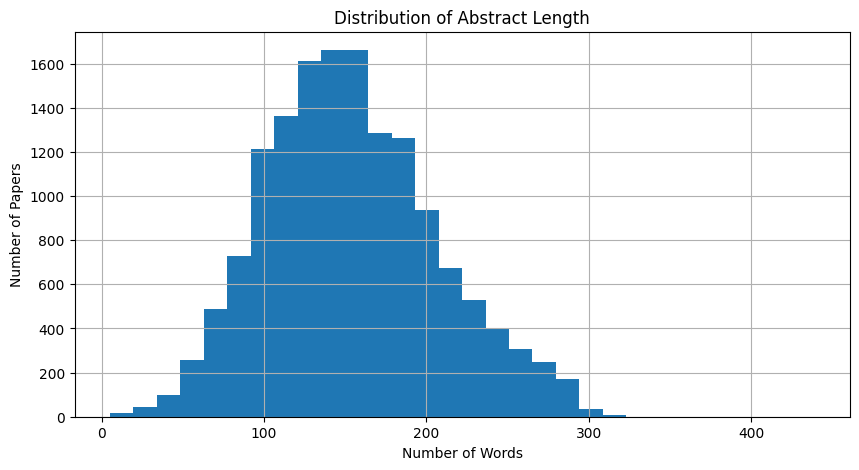

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df["Abstract_Length"], bins=30)

plt.title("Distribution of Abstract Length")

plt.xlabel("Number of Words")

plt.ylabel("Number of Papers")

plt.grid(True)

plt.show()

Word Cloud

In [ ]:
!pip install wordcloud

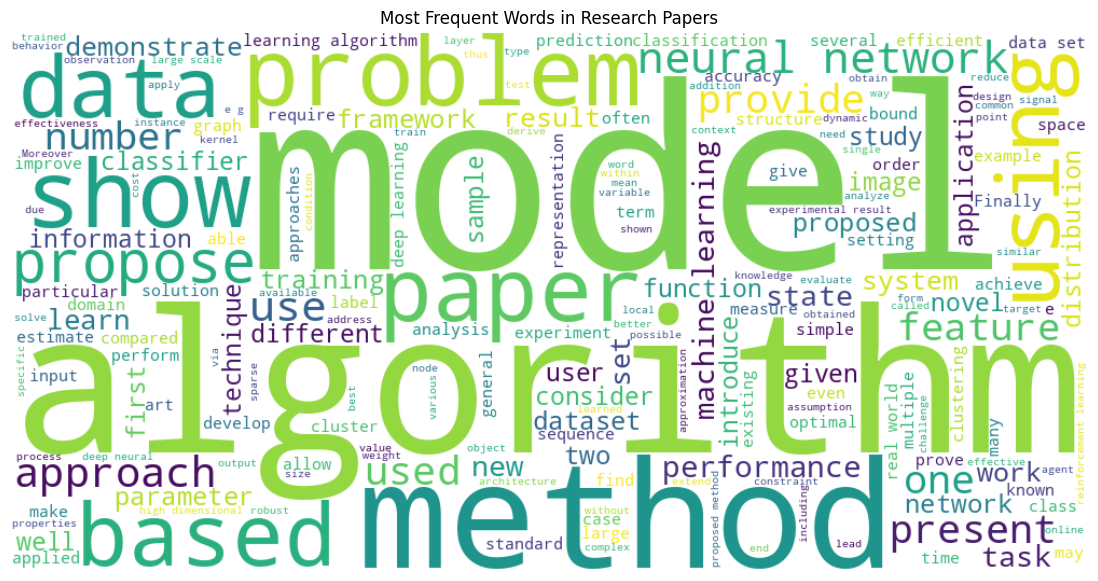

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["abstract"].fillna("").astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Research Papers")
plt.show()